In [22]:
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import pickle 
import seaborn as sns
from visualization import *

## Probing/Intervention Study

In [16]:
with open('./accuracies/gpt_line.pkl', 'rb') as file:
    gpt = pickle.load(file)
with open('./accuracies/gpt-j_line.pkl', 'rb') as file:
    gpt_j = pickle.load(file)
with open('./accuracies/llama_line.pkl', 'rb') as file:
    llama = pickle.load(file)
with open('./accuracies/llama_instruct_line.pkl', 'rb') as file:
    llama_instruct = pickle.load(file)
with open('./accuracies/llama_medium_line.pkl', 'rb') as file:
    llama_medium = pickle.load(file)
with open('./accuracies/llama_medium_instruct_line.pkl', 'rb') as file:
    llama_medium_instruct = pickle.load(file)
with open('./accuracies/pythia_line.pkl', 'rb') as file:
    pythia = pickle.load(file)
with open('./accuracies/pythia_instruct_line.pkl', 'rb') as file:
    pythia_deduped = pickle.load(file)
with open('./accuracies/yi_line.pkl', 'rb') as file:
    yi = pickle.load(file)
with open('./accuracies/yi_instruct_line.pkl', 'rb') as file:
    yi_instruct = pickle.load(file)
with open('./accuracies/gemma_line.pkl', 'rb') as file:
    gemma = pickle.load(file)
with open('./accuracies/gemma_instruct_line.pkl', 'rb') as file:
    gemma_instruct = pickle.load(file)

models = [
          sorted(gpt), sorted(gpt_j), 
          sorted(yi), sorted(yi_instruct), 
          sorted(pythia_deduped), sorted(pythia),  
          sorted(llama_medium), sorted(llama_medium_instruct), 
          sorted(gemma), sorted(gemma_instruct),
          sorted(llama), sorted(llama_instruct) 
          ]
top3 = [model[-3:] for model in models]
top3_avg = [float(np.mean(model)*100) for model in top3]

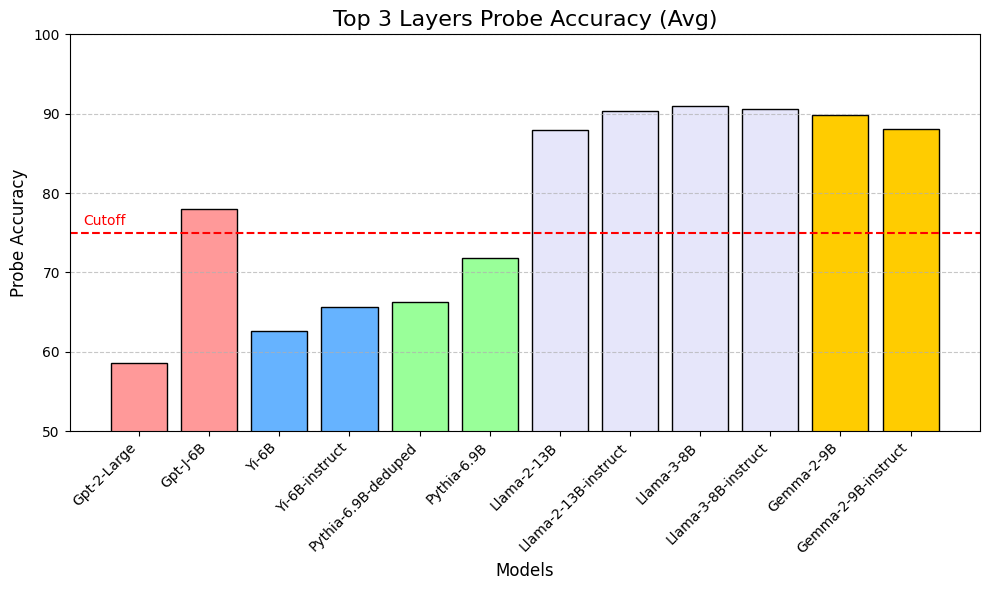

In [17]:
categories = ['Gpt-2-Large', 'Gpt-J-6B', 'Yi-6B', 'Yi-6B-instruct', 'Pythia-6.9B-deduped', 'Pythia-6.9B', 'Llama-2-13B', 'Llama-2-13B-instruct', 'Llama-3-8B', 'Llama-3-8B-instruct', 'Gemma-2-9B', 'Gemma-2-9B-instruct']
values = top3_avg
colors = ['#FF9999', '#FF9999', '#66B3FF', '#66B3FF', '#99FF99', '#99FF99', '#E6E6FA', '#E6E6FA', '#E6E6FA','#E6E6FA', '#FFCC00',  '#FFCC00']

plt.figure(figsize=(10, 6))
bars = plt.bar(categories, values, color=colors, edgecolor='black')
cutoff_value = 75
plt.axhline(y=cutoff_value, color='red', linestyle='--', linewidth=1.5, label='Cutoff')
plt.text(-0.80, cutoff_value + 1, 'Cutoff', color='red', fontsize=10)
plt.title('Top 3 Layers Probe Accuracy (Avg)', fontsize=16)
plt.xlabel('Models', fontsize=12)
plt.ylabel('Probe Accuracy', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.ylim(50, 100)  

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


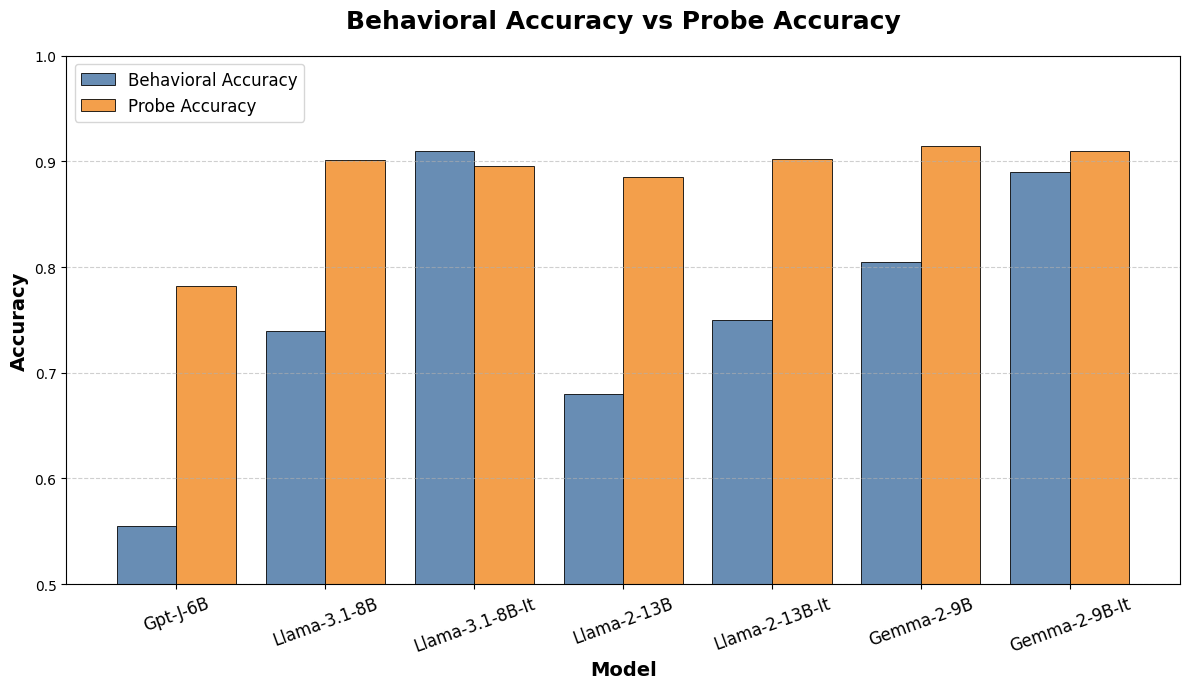

In [ ]:
behav = [(100 - 46 + 100 - 43) / 200,           # Gpt-J-6B
         (100 + 100 - 52) / 200,                # Llama-3.1-8B
         (100 - 1 + 100 - 17) / 200,            # Llama-3.1-8B-It
         (100 - 15 + 100 - 49) / 200,           # Llama-2-13B
         (100 - 28 + 100 - 22) / 200,           # Llama-2-13B-It
         (100 - 5 + 100 - 34) / 200,            # Gemma-2-9B
         (100 - 8 + 100 - 14) / 200]            # Gemma-2-9B-It
accs = [0.782, 0.901, 0.896, 0.885, 0.902, 0.915, 0.910]

indices = np.arange(len(behav))
models = ['Gpt-J-6B', 'Llama-3.1-8B', 'Llama-3.1-8B-It', 'Llama-2-13B', 'Llama-2-13B-It', 'Gemma-2-9B', 'Gemma-2-9B-It']
bar_width = 0.4

plt.figure(figsize=(12, 7))

colors = ['#4E79A7', '#F28E2B']
bars1 = plt.bar(indices - bar_width / 2, behav, bar_width, label='Behavioral Accuracy', color=colors[0], alpha=0.85, edgecolor='black', linewidth=0.7)
bars2 = plt.bar(indices + bar_width / 2, accs, bar_width, label='Probe Accuracy', color=colors[1], alpha=0.85, edgecolor='black', linewidth=0.7)

plt.xlabel('Model', fontsize=14, weight='bold')
plt.ylabel('Accuracy', fontsize=14, weight='bold')
plt.title('Behavioral Accuracy vs Probe Accuracy', fontsize=18, weight='bold', pad=20)
plt.xticks(indices, models, rotation=20, fontsize=12)
plt.ylim(0.5, 1)
plt.legend(fontsize=12, loc='upper left')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [32]:
heads = np.array([99, 90, 97-17, 100-17, 43-28, 97-28, 86-22, 100-22, 17-8, 94-8, 28-14, 99-14])
resid = np.array([90, 97, 91-52, 84-52, 33-15, 87-15, 83-49, 99-49, 80-5, 71, 53-34, 99-34])

print("Avg difference head-resid interventions: ", np.mean(heads-resid))

strengths_r = np.array([0.714, 0.875, 0.625, 0.545, 1.20, 6.428, 2.142, 1.748, 0.765, 0.468, 1.875, 2.6, 4.666, 3.928])
strengths_h = np.array([0.142, 0.312, 0.219, 0.100, 0.050, 1.129, 1.130, 0.640, 0.139, 0.195, 0.150, 0.120, 1.375, 1.130])

strengths_diff = strengths_r - strengths_h
average_strength = np.mean(strengths_diff)
std_strength = np.std(strengths_diff)

print("Average Strength Difference:", average_strength)
print("Standard Deviation of Strength Difference:", std_strength)

Avg difference head-resid interventions:  9.166666666666666
Average Strength Difference: 1.5534285714285712
Standard Deviation of Strength Difference: 1.3920353399806709


In [ ]:
with open('./accuracies/logreg.pkl', 'rb') as file:
    logreg = pickle.load(file)
with open('./accuracies/mlp_1.pkl', 'rb') as file:
    mlp_1 = pickle.load(file)
with open('./accuracies/mlp_2.pkl', 'rb') as file:
    mlp_2 = pickle.load(file)
with open('./accuracies/mlp_3.pkl', 'rb') as file:
    mlp_3 = pickle.load(file)
with open('./accuracies/mmp.pkl', 'rb') as file:
    mmp = pickle.load(file)

top_5_logreg = np.flip(np.sort(logreg)[-5:])
top_5_mmp = np.flip(np.sort(mmp)[-5:])
top_5_mlp_1 = np.flip(np.sort(mlp_1)[-5:])
top_5_mlp_2 = np.flip(np.sort(mlp_2)[-5:])
top_5_mlp_3 = np.flip(np.sort(mlp_3)[-5:])
avg_top_5_logreg = np.mean(top_5_logreg)
avg_top_5_mmp = np.mean(top_5_mmp)
avg_top_5_mlp_1 = np.mean(top_5_mlp_1)
avg_top_5_mlp_2 = np.mean(top_5_mlp_2)
avg_top_5_mlp_3 = np.mean(top_5_mlp_3)

colors = ['#007acc',
        '#d60728',
        '#d65728', 
        '#d6b728', 
        '#2ca02c']
markers = ['o']

pretty_line_mass(logreg, mlp_1, mlp_2, mlp_3,  mmp, 
                 labels=['Logistic Regression', 'MLP (1 H)', 'MLP (2 H)', 'MLP (3 H)', 'MMP'],
                 title='Probe Accuracy on Residual Stream (Llama)',
                 colors = colors,
                 markers = markers)

## Calibration study

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

errors = {'llama': {'ece': {'lr': 0.118, 'mmp': 0.118, 'self': 0.1720}, 'mce': {'lr': 0.26, 'mmp': 0.232, 'self': 0.439}},
          'llama-it': {'ece': {'lr': 0.069, 'mmp': 0.1470, 'self': 0.063}, 'mce': {'lr': 0.1920, 'mmp': 0.2570, 'self': 0.1510}},
          'gemma': {'ece': {'lr': 0.068, 'mmp': 0.117, 'self': 0.086}, 'mce': {'lr': 0.16, 'mmp': 0.237, 'self': 0.293}},
          'gemma-it': {'ece': {'lr': 0.066, 'mmp': 0.089, 'self': 0.028}, 'mce': {'lr': 0.263, 'mmp': 0.263, 'self': 0.111}},
          'gptj': {'ece': {'lr': 0.283, 'mmp': 0.379, 'self': 0.256}, 'mce': {'lr': 0.544, 'mmp': 0.621, 'self': 0.519}}}

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Flatten the nested dictionary into a DataFrame
rows = []
for model, metrics in errors.items():
    for error_type, methods in metrics.items():
        for method, value in methods.items():
            rows.append({
                'Model': model,
                'Error Type': error_type.upper(),  # ECE or MCE
                'Calibration Method': method,
                'Error Value': value
            })

df = pd.DataFrame(rows)

# Set desired color palette
palette = {
    'lr': '#4C72B0',     # default blue
    'mmp': '#55A868',    # green
    'self': '#8172B2'    # purple
}

# Sort calibration method to keep bar order consistent
df['Calibration Method'] = pd.Categorical(df['Calibration Method'], categories=['lr', 'mmp', 'self'], ordered=True)

# Plot
sns.set(style="whitegrid", font_scale=1.1)
g = sns.catplot(
    data=df,
    x='Model',
    y='Error Value',
    hue='Calibration Method',
    col='Error Type',
    kind='bar',
    height=5,
    aspect=1.4,
    palette=palette,
    sharey=False
)

g.set_titles("{col_name}")
g.set_axis_labels("Model", "Error")
# Remove shared legend
g._legend.remove()

# Add it to first subplot (ECE)
handles, labels = g.axes[0, 0].get_legend_handles_labels()
g.axes[0, 0].legend(
    handles, labels,
    loc='upper left',
    title='Estimator',
    frameon=True  # optional: removes border around legend
)
g.set_xticklabels(rotation=45, ha='right')

# Rotate x labels
for ax in g.axes.flatten():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def nice_boxplot(
    data,
    x=None,
    y=None,
    hue=None,
    title=None,
    xlabel=None,
    ylabel=None,
    palette="Set2",
    figsize=(10, 6),
    showfliers=True,
    orient=None,
    linewidth=1.5,
    fontsize=12,
    rotation=0,
    boxprops=None,
    whiskerprops=None,
    capprops=None,
    medianprops=None,
    show_points=False
):
    """
    Creates a high-quality boxplot with optional enhancements.

    Parameters:
        data (pd.DataFrame): The input data.
        x, y (str): Column names for axis mapping.
        hue (str): Column name for color grouping.
        title (str): Plot title.
        xlabel, ylabel (str): Axis labels.
        palette (str or list): Color palette.
        figsize (tuple): Figure size.
        showfliers (bool): Whether to show outliers.
        orient (str): "h" or "v" orientation.
        linewidth (float): Width of lines.
        fontsize (int): Font size for labels and title.
        rotation (int): Rotation of x-axis labels.
        show_points (bool): Overlay stripplot if True.
    """
    sns.set(style="whitegrid")
    plt.figure(figsize=figsize)

    boxprops = boxprops or dict(linewidth=linewidth)
    whiskerprops = whiskerprops or dict(linewidth=linewidth)
    capprops = capprops or dict(linewidth=linewidth)
    medianprops = medianprops or dict(linewidth=linewidth, color='black')

    ax = sns.boxplot(
        data=data,
        x=x,
        y=y,
        hue=hue,
        palette=palette,
        orient=orient,
        showfliers=showfliers,
        linewidth=linewidth,
        boxprops=boxprops,
        whiskerprops=whiskerprops,
        capprops=capprops,
        medianprops=medianprops
    )

    if show_points:
        sns.stripplot(
            data=data,
            x=x,
            y=y,
            hue=hue if hue and not data[hue].duplicated().all() else None,
            palette=palette,
            dodge=True,
            alpha=0.4,
            zorder=1
        )

    if title:
        ax.set_title(title, fontsize=fontsize + 2)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=fontsize)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=fontsize)

    ax.tick_params(labelsize=fontsize)
    plt.xticks(rotation=rotation)

    if hue:
        plt.legend(title=hue, fontsize=fontsize - 1, title_fontsize=fontsize)

    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

# Settings
n_samples = 500
categories = ['A', 'B', 'C', 'D']
subgroups = ['X', 'Y']

# Create synthetic data
data = []
for cat in categories:
    for sub in subgroups:
        mu = np.random.uniform(5, 20)           # Mean varies per group
        sigma = np.random.uniform(1.0, 4.0)      # Std dev varies
        vals = np.random.normal(mu, sigma, size=n_samples)
        # Add a few outliers
        outliers = np.random.normal(mu + 10, sigma * 1.5, size=5)
        vals = np.concatenate([vals, outliers])
        for val in vals:
            data.append({'Category': cat, 'Subgroup': sub, 'Value': val})

df = pd.DataFrame(data)


In [ ]:
import numpy as np

def standardize(array):

    mean = np.mean(array)
    std_dev = np.std(array)
    standardized_array = array
    for i in range(len(array)):
        standardized_array[i] = (array[i] - mean) / std_dev
    
    return standardized_array

neg = np.array([
    0.8217, 0.7236, 0.8340, 0.9223, 0.7393,
    0.6483, 0.8448, 0.8853, 0.7674, 0.6682,
    0.8372, 0.9445, 0.8282, 0.7611, 0.8414,
    0.8457, 0.7296, 0.6221, 0.5701, 0.9304, 0.795
])
disj = np.array([
    0.3147, 0.3515, 0.4821, 0.4916, 0.4352,
    0.5546, 0.5167, 0.7204, 0.6083, 0.5141,
    0.5526, 0.7240, 0.4400, 0.3956, 0.5990,
    0.5676, 0.4642, 0.4972, 0.4489, 0.4972, 0.504
])

conj = np.array([
    0.6071, 0.5535, 0.4414, 0.5563, 0.4564,
    0.2857, 0.5133, 0.5491, 0.4884, 0.5107,
    0.4103, 0.4645, 0.7510, 0.4519, 0.7048,
    0.5906, 0.8537, 0.6662, 0.4795, 0.2667, 0.517
])
inf = np.array([
    0.5705, 0.6366, 0.6952, 0.7338, 0.7111,
    0.6860, 0.7233, 0.7681, 0.7086, 0.6477,
    0.6958, 0.7548, 0.7658, 0.8101, 0.8111,
    0.8865, 0.6144, 0.6157, 0.6791, 0.7424, 0.444
])
inf_ = np.array([
    0.6572, 0.6635, 0.7382, 0.8171, 0.7609,
    0.7304, 0.7509, 0.8075, 0.7049, 0.6396,
    0.7490, 0.8279, 0.7980, 0.8979, 0.8325,
    0.9080, 0.6578, 0.6544, 0.7239, 0.9252, 0.477
])

cross = np.array([
    [-4.95, -5.48, -1.95, 28.28, 3.55, -0.20, 10.70, 47.62, -1.92, 4.84, 1.78, 28.23, 4.31, 15.80, 1.42, 41.78, -13.09, -6.70, 12.76, 6.62],
    [-5.52, -10.14, 5.14, 15.85, 7.20, 2.70, 3.99, 11.96, 6.76, 4.92, 6.96, 23.26, 0.72, -0.21, 7.71, 15.09, 3.20, -0.20, 0.12, -0.30],
    [2.82, 2.47, 0.10, 6.51, -1.30, 0.30, 3.16, 5.82, -3.45, -1.03, 2.73, 0.31, -1.97, -3.04, 0.51, -0.20, -8.43, -5.11, -8.84, -15.23]
]) / 100

In [ ]:
likely = cross[0, :]
tqa = cross[1, :]
mulan = cross[2, :]

likely_llama, likely_llama_it, likely_gemma, likely_gemma_it, likely_gptj = np.array_split(likely, 5)
tqa_llama, tqa_llama_it, tqa_gemma, tqa_gemma_it, tqa_gptj = np.array_split(tqa, 5)
mulan_llama, mulan_llama_it, mulan_gemma, mulan_gemma_it, mulan_gptj = np.array_split(mulan, 5)

likely_lr = likely[::4]
tqa_lr = tqa[::4]
mulan_lr = mulan[::4]
likely_mmp = likely[1::4]
tqa_mmp = tqa[1::4]
mulan_mmp = mulan[1::4]
likely_self = likely[2::4]
tqa_self = tqa[2::4]
mulan_self = mulan[2::4]
likely_logit = likely[3::4]
tqa_logit = tqa[3::4]
mulan_logit = mulan[3::4]

In [ ]:
cross_models = {
    'llama': {
        'likely': likely_llama,
        'tqa': tqa_llama,
        'mulan': mulan_llama
    },
    'llama_it': {
        'likely': likely_llama_it,
        'tqa': tqa_llama_it,
        'mulan': mulan_llama_it
    },
    'gemma': {
        'likely': likely_gemma,
        'tqa': tqa_gemma,
        'mulan': mulan_gemma
    },
    'gemma_it': {
        'likely': likely_gemma_it,
        'tqa': tqa_gemma_it,
        'mulan': mulan_gemma_it
    },
    'gptj': {
        'likely': likely_gptj *1.5,  # Adjusted for visualization
        'tqa': tqa_gptj,
        'mulan': mulan_gptj
    }
}

cross_estimators = {
    'lr': {
        'likely': likely_lr,
        'tqa': tqa_lr,
        'mulan': mulan_lr
    },
    'mmp': {
        'likely': likely_mmp,
        'tqa': tqa_mmp,
        'mulan': mulan_mmp
    },
    'self': {
        'likely': likely_self,
        'tqa': tqa_self,
        'mulan': mulan_self
    },
    'logit': {
        'likely': likely_logit,
        'tqa': tqa_logit,
        'mulan': mulan_logit
    }
}

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Get average scores
def get_means(data_dict):
    return {
        name: {k: np.mean(v) for k, v in metrics.items()}
        for name, metrics in data_dict.items()
    }

model_means = get_means(cross_models)
estimator_means = get_means(cross_estimators)

# Step 2: Prepare data for plotting
def extract_plot_data(means_dict):
    labels = list(means_dict.keys())
    likely_vals = [means_dict[k]['likely'] for k in labels]
    tqa_vals = [means_dict[k]['tqa'] for k in labels]
    mulan_vals = [means_dict[k]['mulan'] for k in labels]
    return labels, likely_vals, tqa_vals, mulan_vals

model_labels, model_likely, model_tqa, model_mulan = extract_plot_data(model_means)
est_labels, est_likely, est_tqa, est_mulan = extract_plot_data(estimator_means)

# Step 3: Plot settings
width = 0.25
colors = ['#4070A8', '#F58518', '#54A24B'] # Blue, Orange, Green

fig, axs = plt.subplots(1, 2, figsize=(18, 6), constrained_layout=True)
fig.suptitle("Cross-Dataset Task Performance", fontsize=16, fontweight='bold')

# Helper to plot each set
def plot_bars(ax, x, labels, vals1, vals2, vals3, title):
    ax.bar(x - width, vals1, width, label='Likely', color=colors[0],
           alpha=0.8, edgecolor='black', linewidth=0.75)
    ax.bar(x, vals2, width, label='TQA', color=colors[1],
           alpha=0.8, edgecolor='black', linewidth=0.75)
    ax.bar(x + width, vals3, width, label='MULAN', color=colors[2],
           alpha=0.8, edgecolor='black', linewidth=0.75)
    
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
    ax.axhline(0, color='gray', linestyle='dashed', linewidth=1.2)
    ax.set_title(title, fontsize=13)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.legend()


# --- Plot models
x1 = np.arange(len(model_labels))
plot_bars(axs[0], x1, model_labels, model_likely, model_tqa, model_mulan, "Models")

# --- Plot estimators
x2 = np.arange(len(est_labels))
plot_bars(axs[1], x2, est_labels, est_likely, est_tqa, est_mulan, "Estimators")

plt.show()



In [ ]:
all_metrics = np.column_stack((neg, disj, conj, inf_, inf))
scaler = StandardScaler()
standardized_metrics = scaler.fit_transform(all_metrics)

In [ ]:
''' Check Irwin-Hall '''

import matplotlib.pyplot as plt

t1 = np.random.rand(1000)
t2 = np.random.rand(1000)
t3 = t1 + t2

plt.figure(figsize=(10, 15))
plt.hist(t1, bins=30, alpha=0.5, color='blue', label='t1')
plt.hist(t2, bins=30, alpha=0.5, color='orange', label='t2')
plt.hist(t3, bins=30, alpha=0.5, color='green', label='t3')

In [ ]:
('raw', all_metrics.min(), all_metrics.max(), all_metrics.mean(), all_metrics.std()), \
('scaled', standardized_metrics.min(), standardized_metrics.max(), standardized_metrics.mean(), standardized_metrics.std())

In [ ]:
it_self = np.stack((standardized_metrics[6, :].T, standardized_metrics[14, :].T))
base_self = np.stack((standardized_metrics[2, :].T, standardized_metrics[10, :].T))
self_delta = np.mean(it_self - base_self)
it_logit = np.stack((standardized_metrics[7, :].T, standardized_metrics[15, :].T))
base_logit = np.stack((standardized_metrics[3, :].T, standardized_metrics[11, :].T))
logit_delta = np.mean(it_logit - base_logit)
it_lr = np.stack((standardized_metrics[4, :].T, standardized_metrics[12, :].T))
base_lr = np.stack((standardized_metrics[0, :].T, standardized_metrics[8, :].T))
lr_delta = np.mean(it_lr - base_lr)
it_mm = np.stack((standardized_metrics[5, :].T, standardized_metrics[13, :].T))
base_mm = np.stack((standardized_metrics[1, :].T, standardized_metrics[9, :].T))
mm_delta = np.mean(it_mm - base_mm)

In [ ]:
import matplotlib.pyplot as plt

# Define the data
labels = ['Self', 'Logit', 'LR', 'MM']
deltas = [self_delta, logit_delta, lr_delta, mm_delta]
colors = {
    'Self': '#a88ac1',   # soft purple
    'Logit': '#f4a261',  # soft orange
    'LR': '#6ca0dc',     # soft blue
    'MM': '#8fc98f'      # soft green
}

# Sort the data by delta values (descending)
sorted_items = sorted(zip(labels, deltas), key=lambda x: x[1], reverse=True)
sorted_labels, sorted_deltas = zip(*sorted_items)
sorted_colors = [colors[label] for label in sorted_labels]

# Plotting
plt.figure(figsize=(6, 6))
bars = plt.bar(
    sorted_labels,
    sorted_deltas,
    color=sorted_colors,
    alpha=0.9,
    edgecolor='black',
    linewidth=1.2,
    width=0.6
)

# Aesthetics
plt.ylabel('Average Score Difference (IFT - Base Model)', fontsize=12)
plt.title('Difference in Performance for IFT and Base Models', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.margins(x=0.1)
plt.tight_layout()

plt.show()


In [ ]:
llama = standardized_metrics[0:4, :].T
llama_it = standardized_metrics[4:8, :].T
gemma = standardized_metrics[8:12, :].T
gemma_it = standardized_metrics[12:16, :].T
gpt_j = standardized_metrics[16:20, :].T
baseline = standardized_metrics[-1:, :].T
lr = np.stack((standardized_metrics[0, :].T, standardized_metrics[4, :].T, 
             standardized_metrics[8, :].T, standardized_metrics[12, :].T, standardized_metrics[16, :].T))
lr_random = np.array([-0.26934981, 0.09518319, -0.09170219, -2.77262399, -2.62858693])  
mm = np.stack((standardized_metrics[1, :].T, standardized_metrics[5, :].T, 
             standardized_metrics[9, :].T, standardized_metrics[13, :].T, standardized_metrics[17, :].T))
mm_random = np.array([-0.64496456, 0.09518319, -0.09170219, -2.77262399, -2.62858693])  
self = np.stack((standardized_metrics[2, :].T, standardized_metrics[6, :].T, 
             standardized_metrics[10, :].T, standardized_metrics[14, :].T, standardized_metrics[18, :].T))
self_random = np.array([0.3023748, 0.09518319, -0.09170219, -2.77262399, -2.62858693])  
logit = np.stack((standardized_metrics[3, :].T, standardized_metrics[7, :].T, 
             standardized_metrics[11, :].T, standardized_metrics[15, :].T, standardized_metrics[19, :].T))
logit_random = np.array([0.85964074, 0.09518319, -0.09170219, -2.77262399, -2.62858693])  

In [ ]:
estimators = {
              'lr': lr.flatten(),
              'mm': mm.flatten(),
              'self': self.flatten(),
              'logit': logit.flatten(),
              'lr_random': lr_random,
              'mm_random': mm_random,
              'self_random': self_random,
              'logit_random': logit_random
              }
models = {
            'llama': llama.flatten(),
            'llama-it': llama_it.flatten(),
            'gemma': gemma.flatten(),
            'gemma-it': gemma_it.flatten(),
            'gpt-j': gpt_j.flatten(),
            'baseline': baseline.flatten()
            }

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare dataframe
data = []
for key, values in estimators.items():
    model = key.replace('_random', '')
    variant = 'Baseline' if 'random' in key else 'Estimator'
    for v in values:
        data.append({'Model': model, 'Variant': variant, 'Score': float(v)})

df = pd.DataFrame(data)
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')
model_order = ['lr', 'mm', 'self', 'logit']

# Set style
sns.set_theme(style='whitegrid')

# Color palette
palette = sns.color_palette('Set2')

# Plot
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df,
    x='Model',
    y='Score',
    hue='Variant',
    order=model_order,
    palette=palette,
    width=0.8,
    linewidth=0.75,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7,
    },
)

# Aesthetic tweaks
plt.title('Estimator Scores (Coherence)', fontsize=18, weight='bold', pad=15)
plt.xlabel('Estimator', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='', title_fontsize=13, fontsize=11, loc='upper left')
sns.despine(trim=False)
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
models = {  
    'LR (Base model)': base_lr.flatten(),
    'LR (IFT)': it_lr.flatten(),
    'MM (Base model)': base_mm.flatten(),
    'MM (IFT)': it_mm.flatten(),
    'Self-reporting (Base model)': base_self.flatten(),
    'Self-reporting (IFT)': it_self.flatten(),
    'Logits (Base model)': base_logit.flatten(),
    'Logits (IFT)': it_logit.flatten(),
            }

In [ ]:
models['llama']

In [ ]:
df

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare dataframe
data = []
for key, values in models.items():
    variant = 'Base' if not key.endswith('IFT)') else 'IFT'
    for v in values:
        data.append({'Model': key, 'Variant': variant, 'Score': float(v)})

df = pd.DataFrame(data)
df[['Model_Name', 'Variant']] = df['Model'].str.extract(r'^(.*?)\s*\((.*?)\)$')
df['Variant'] = df['Variant'].replace({
    'Base model': 'Base',
    'IFT': 'IFT'
})

# Reorder if needed
model_order = df['Model_Name'].unique()
df['Score'] = pd.to_numeric(df['Score'], errors='coerce')

# Set style
sns.set_theme(style='whitegrid')

# Build custom alternating color palette
unique_models = sorted(df['Model'].unique())
light_color = '#3030c9'  # light blue
dark_color = '#d0e1ff' 

model_colors = {}
for i, model in enumerate(unique_models):
    model_colors[model] = light_color if i % 2 == 0 else dark_color

# Map colors by Model (not by Variant)
palette = df['Model'].map(model_colors).to_dict()
custom_palette = [model_colors[model] for model in df['Model'].unique()]
print(custom_palette)

# Plot
plt.figure(figsize=(10, 6))
ax = sns.boxplot(
    data=df,
    x='Model_Name',
    y='Score',
    hue='Variant',
    palette=custom_palette,  # this works if hue is 'Model'; for 'Variant', see note below
    width=0.8,
    linewidth=0.75,
    showmeans=True,
    meanprops={
        "marker": "o",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7,
    },
)

# Aesthetic tweaks
plt.title('Model Scores (IFT vs Base Models)', fontsize=18, weight='bold', pad=15)
plt.xlabel('Condition', fontsize=14)
plt.ylabel('Score', fontsize=14)
plt.xticks(fontsize=12, rotation=40)
plt.yticks(fontsize=12)
plt.legend(title='', title_fontsize=13, fontsize=11, loc='upper left')
sns.despine(trim=False)
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.show()


In [ ]:
test_lr = [split[0, 4] for split in np.array_split(lr, 5)]
test_lr_baseline = lr_random[4]
test_mm = [split[0, 4] for split in np.array_split(mm, 5)]
test_mm_baseline = mm_random[4]
test_self = [split[0, 4] for split in np.array_split(self, 5)]
test_self_baseline = self_random[4]
test_logit = [split[0, 4] for split in np.array_split(logit, 5)]
test_logit_baseline = logit_random[4]

In [ ]:
lr_score = np.mean(test_lr)
lr_random_score = np.mean(lr_random)
mm_score = np.mean(test_mm)
mm_random_score = np.mean(mm_random)
self_score = np.mean(test_self)
self_random_score = np.mean(self_random)
logit_score = np.mean(test_logit)
logit_random_score = np.mean(logit_random)


scores = {
    'lr': lr_score,
    'mm': mm_score,
    'self': self_score,
    'logit': logit_score,
    'lr_random': test_lr_baseline,
    'mm_random': test_mm_baseline,
    'self_random': test_self_baseline,
    'logit_random': test_logit_baseline
}

In [ ]:
# Organize scores for side-by-side comparison
model_names = ["lr", "mm", "self", "logit"]
actual_scores = [scores["lr"], scores["mm"], scores["self"], scores["logit"]]
random_scores = [scores["lr_random"], scores["mm_random"], scores["self_random"], scores["logit_random"]]

x = np.arange(len(model_names))  # label locations
width = 0.35  # width of the bars

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, actual_scores, width, label='Estimator', edgecolor='black')
bars2 = ax.bar(x + width/2, random_scores, width, label='Random Baseline', edgecolor='black', alpha=0.7)

# Custom styling
ax.set_ylabel("Estimator Score", fontsize=12)
ax.set_title("Performances on Implication*", fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.hist(inf_)

In [ ]:

inf_